In [1]:
import warnings
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 忽略 Seaborn/Pandas 产生的 CategoricalDtype 弃用警告
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

# 自动选择 Mac / Windows / Linux 已安装的中文字体。
from pathlib import Path
from matplotlib import font_manager

# Mac 的补充字体可能没有进入 Matplotlib 原有字体列表。
for font_path in [
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
]:
    if Path(font_path).is_file():
        try:
            font_manager.fontManager.addfont(font_path)
        except (OSError, RuntimeError) as exc:
            warnings.warn(f"无法注册字体 {font_path}: {exc}")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = [
    "PingFang SC", "Heiti SC", "Songti SC", "STHeiti",
    "Microsoft YaHei", "SimHei", "Noto Sans CJK SC",
    "Source Han Sans SC", "WenQuanYi Micro Hei", "Arial Unicode MS",
]
chinese_font = next((name for name in preferred_fonts if name in available_fonts), None)
if chinese_font is None:
    raise RuntimeError(
        "未找到中文字体，请安装 Noto Sans CJK SC 或思源黑体，重启内核后重试。"
    )

# 先设置 Seaborn 风格，再设置字体，避免主题覆盖字体配置。
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [chinese_font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# print(f"绘图中文字体：{chinese_font}")
# 数据来源配置：切换后重启内核并运行全部单元格。
USE_BBG = True  # True：查询彭博并保存缓存；False：只读取缓存
CACHE_ROOT = "bloomberg_cache"
CACHE_DIR = None  # None：使用最新完整缓存；也可指定某个时间戳目录

# 开平仓匹配文件：更换报告日期时一起更新。
OPEN_POSITION_FILE = "镒链系统20260916开仓导出.xlsb"
CLOSE_POSITION_FILE = "平仓_20260916.xlsx"


In [2]:
# ==========================================
# 0. 过滤国内交易所合约 (如 pd2606.GFE, zn2507.SHFE)
# ==========================================
def filter_onshore_contracts(df, ticker_col='标的全称'):
    """
    过滤掉标的全称为国内交易所格式的合约 (.GFE, .SHFE, .DCE, .CZCE, .CFFEX, .INE)
    """
    pattern = r'\.(?:GFE|SHFE|DCE|CZCE|CFFEX|INE)$'
    mask = df[ticker_col].astype(str).str.contains(pattern, case=False, na=False)
    filtered_df = df[~mask].copy()
    # print(f"过滤国内交易所合约完成：共移除 {mask.sum()} 条数据，剩余 {len(filtered_df)} 条数据。")
    return filtered_df

In [3]:
# ==========================================
# 1. 剔除交易所后缀的清洗函数
# ==========================================
def clean_ticker(ticker):
    if pd.isna(ticker):
        return ticker
    return re.sub(r'\.[A-Za-z0-9]+$', '', str(ticker).strip())

In [4]:
def convert_to_generic_ticker(ticker):
    """
    将具体的期货/期权/LME合约 Ticker 转换为彭博通用主连 Ticker (Generic Ticker)
    
    规则示例：
      1. LME 合约（如 LMZSDP 20261216 Comdty / LMZSDP Comdty） -> 'LMZSDY Comdty'
      2. 外汇/现货标的（如 XPTUSD Curncy）                      -> 'XPTUSD Curncy' (保持原样)
      3. 带空格的农产品合约（如 W Z6 Comdty, C Z6 Comdty）      -> 'W 1 Comdty', 'C 1 Comdty'
      4. 中国金融期货（如 IF2609 Index）                        -> 'IF1 Index'
      5. 无空格标准期货（如 CLZ6 Comdty）                        -> 'CL1 Comdty'
    """
    if not ticker or not isinstance(ticker, str):
        return ticker

    ticker = ticker.strip()
    # 带日期的贵金属合约使用现货代码查询，避免生成 XPTUSD1。
    precious_pair = re.match(r'^(XPT|XPD|XAU|XAG)(USD|CNH)(?=\s|$)', ticker, re.IGNORECASE)
    if precious_pair:
        return f"{precious_pair.group(0).upper()} Curncy"

    
    # 匹配彭博 Yellow Key (Comdty, Curncy, Index, Govt, Corp 等)
    yk_match = re.search(r'\b(Comdty|Curncy|Index|Govt|Corp)\b', ticker, re.IGNORECASE)
    if not yk_match:
        return ticker

    yellow_key = yk_match.group(1)
    prefix = ticker[:yk_match.start()].strip()

    # 外汇/贵金属现货标的（如 XPTUSD Curncy, EURUSD Curncy）保持原代码不变
    if yellow_key.lower() == 'curncy' and not re.search(r'[FGHJKMNQUVXZ]\d|\d{3,4}', prefix, re.IGNORECASE):
        return ticker

    # 规则 1：处理 LME 格式代码（支持带年月日如 LMZSDP 20261216 或不带日期的 LMZSDP）
    lme_match = re.match(r'^(LM[A-Z]{3})[A-Z0-9]*', prefix, re.IGNORECASE)
    if lme_match:
        base = lme_match.group(1)
        # 截取前 5 位（如 LMZSD）并统一替换最后一个字母为 Y -> LMZSDY
        return f"{base[:5]}Y {yellow_key}"

    # 规则 2：处理带空格的品种代码（如 W Z6, C Z6 -> W 1, C 1）
    space_code_match = re.match(r'^([A-Za-z]+)\s+[FGHJKMNQUVXZ]\d', prefix, re.IGNORECASE)
    if space_code_match:
        return f"{space_code_match.group(1)} 1 {yellow_key}"

    # 规则 3：匹配数字年月格式（如 IF2609 -> IF1 Index）
    m_num = re.match(r'^([A-Za-z]+)\d{3,4}', prefix)
    if m_num:
        return f"{m_num.group(1)}1 {yellow_key}"

    # 规则 4：匹配标准无空格合约格式（如 CLZ6 -> CL1 Comdty）
    m_month = re.match(r'^([A-Za-z]+?)[FGHJKMNQUVXZ]\d', prefix, re.IGNORECASE)
    if m_month:
        return f"{m_month.group(1)}1 {yellow_key}"

    # 规则 5：兜底提取开头的字母
    m_root = re.match(r'^([A-Za-z]+)', prefix)
    if m_root:
        return f"{m_root.group(1)}1 {yellow_key}"

    return ticker

In [5]:
# ==========================================
# 3. 彭博数据调取函数（含计价币种与 USD 汇率转换）
# ==========================================

def _positive_number(value):
    """缺失或无效数字保留为 None，只有有限正数可用。"""
    try:
        number = float(value)
    except (TypeError, ValueError):
        return None
    return number if np.isfinite(number) and number > 0 else None


def _read_bbg_field(fields, name, numeric=False):
    """保留彭博缺失和 null，不提前填入业务默认值。"""
    if not fields.hasElement(name) or fields.getElement(name).isNull():
        return None
    if numeric:
        return _positive_number(fields.getElementAsFloat(name))
    return fields.getElementAsString(name).strip() or None


def _precious_metal_override(ticker):
    """贵金属合约的业务规则，不依赖彭博是否返回数据。"""
    if not isinstance(ticker, str):
        return {}
    code = ticker.strip().upper()
    if not code.startswith(('XPT', 'XPD', 'XAU', 'XAG')):
        return {}
    info = {"Contract_Size": 1.0, "Category": "Precious Metal"}
    pair = re.match(r'^(XPT|XPD|XAU|XAG)(USD|CNH)(?=\s|$)', code)
    if pair:
        info["Currency"] = pair.group(2)
    return info


def _contract_override(ticker):
    """显式业务规则优先于彭博数据；仅覆盖指定合约，不扩展到其他月份。"""
    info = _precious_metal_override(ticker)
    if not isinstance(ticker, str):
        return info
    code = " ".join(ticker.upper().split())
    if not code:
        return info
    if code.startswith("HCT"):
        info["Currency"] = "HKD"
        info["Contract_Size"] = 50
    if code.startswith("DM"):
        info["Contract_Size"] = 5
    if code == 'HIK5 INDEX':
        info["Currency"] = "HKD"
    currency_by_contract = {"BOK5": "USD", "ADM5": "AUD", "ECM5": "EUR"}
    currency = currency_by_contract.get(code.split()[0])
    if currency:
        info["Currency"] = currency
    if code.endswith("NDF"):
        info.update({"Contract_Size": 1.0, "Currency": "USD"})
    return info


def get_bloomberg_data(tickers):
    """
    通过 Bloomberg API 调取合约乘数、分类字段以及合约计价币种，
    并自动调取非 USD 币种兑 USD 的即期汇率，实现美元统一计价。
    """
    try:
        import blpapi
    except ImportError as exc:
        raise ImportError("在线模式需要安装 blpapi 并连接彭博终端；离线请设置 USE_BBG=False。") from exc

    ticker_map = {t: convert_to_generic_ticker(t) for t in tickers}
    generic_tickers = list(set(ticker_map.values()))

    # 增加 "CRNCY" 字段以获取合约的计价币种
    fields = ["FUT_CONT_SIZE", "FUTURES_CATEGORY", "MARKET_SECTOR_DES", "COMMODITY_GROUP", "CRNCY"]

    sessionOptions = blpapi.SessionOptions()
    sessionOptions.setServerHost("localhost")
    sessionOptions.setServerPort(8194)
    session = blpapi.Session(sessionOptions)

    if not session.start() or not session.openService("//blp/refdata"):
        raise ConnectionError("无法连接到 Bloomberg API Session，请确保彭博终端已启动。")

    refDataService = session.getService("//blp/refdata")

    # ----------------------------------------------------
    # 第一步：调取合约基本信息 (Multiplier, Category, Currency)
    # ----------------------------------------------------
    request = refDataService.createRequest("ReferenceDataRequest")
    all_tickers_to_query = list(set(list(tickers) + generic_tickers))
    for t in all_tickers_to_query:
        request.append("securities", t)

    for f in fields:
        request.append("fields", f)

    session.sendRequest(request)

    raw_bbg_data = {}
    # 即使彭博返回 securityError，也要请求业务规则指定的非美元汇率。
    overrides = {t: _contract_override(t) for t in tickers}
    currencies_needed = {
        info["Currency"] for info in overrides.values()
        if info.get("Currency") and info["Currency"] != "USD"
    }

    while True:
        event = session.nextEvent(500)
        if event.eventType() in [blpapi.Event.RESPONSE, blpapi.Event.PARTIAL_RESPONSE]:
            for msg in event:
                if msg.hasElement("securityData"):
                    sec_array = msg.getElement("securityData")
                    for i in range(sec_array.numValues()):
                        sec_data = sec_array.getValueAsElement(i)
                        security = sec_data.getElementAsString("security")
                        if sec_data.hasElement("securityError") or not sec_data.hasElement("fieldData"):
                            continue
                        field_data = sec_data.getElement("fieldData")

                        cont_size = _read_bbg_field(field_data, "FUT_CONT_SIZE", numeric=True)
                        fut_cat = field_data.getElementAsString("FUTURES_CATEGORY") if field_data.hasElement("FUTURES_CATEGORY") else ""
                        mkt_sector = field_data.getElementAsString("MARKET_SECTOR_DES") if field_data.hasElement("MARKET_SECTOR_DES") else ""
                        # comdty_grp = field_data.getElementAsString("COMMODITY_GROUP") if field_data.hasElement("COMMODITY_GROUP") else ""
                        currency = _read_bbg_field(field_data, "CRNCY")

                        category = fut_cat or mkt_sector or "Unclassified"
                        
                        # 针对外汇/现货贵金属标的（如 XPTUSD Curncy / XAUUSD Curncy）的规则优化
                        if security.startswith("XPT") or security.startswith("XAU") or security.startswith("XAG") or security.startswith("XPD"):
                            category = "Precious Metal"
                            
                        # 保留大小写；GBp 等子单位不能静默转为 GBP，需要明确换算规则。

                        if currency and currency != "USD" and re.fullmatch(r"[A-Z]{3}", currency):
                            currencies_needed.add(currency)

                        raw_bbg_data[security] = {
                            "Contract_Size": cont_size,
                            "FUTURES_CATEGORY": category,
                            "Currency": currency
                        }

        if event.eventType() == blpapi.Event.RESPONSE:
            break

    # ----------------------------------------------------
    # 第二步：调取外汇即期汇率 (转换为折算美元系数)
    # ----------------------------------------------------
    fx_rates = {"USD": 1.0}

    if currencies_needed:
        fx_request = refDataService.createRequest("ReferenceDataRequest")
        fx_ticker_map = {}

        for ccy in currencies_needed:
            # 尝试直接调取 CCYUSD Curncy (如 EURUSD Curncy, GBPUSD Curncy)
            fx_ticker = f"{ccy}USD Curncy"
            fx_ticker_map[fx_ticker] = ccy
            fx_request.append("securities", fx_ticker)

        fx_request.append("fields", "PX_LAST")
        session.sendRequest(fx_request)

        while True:
            event = session.nextEvent(500)
            if event.eventType() in [blpapi.Event.RESPONSE, blpapi.Event.PARTIAL_RESPONSE]:
                for msg in event:
                    if msg.hasElement("securityData"):
                        sec_array = msg.getElement("securityData")
                        for i in range(sec_array.numValues()):
                            sec_data = sec_array.getValueAsElement(i)
                            sec_name = sec_data.getElementAsString("security")
                            if sec_data.hasElement("securityError") or not sec_data.hasElement("fieldData"):
                                continue
                            field_data = sec_data.getElement("fieldData")
                            ccy = fx_ticker_map.get(sec_name)
                            rate = _read_bbg_field(field_data, "PX_LAST", numeric=True)
                            if ccy and rate is not None:
                                fx_rates[ccy] = rate

            if event.eventType() == blpapi.Event.RESPONSE:
                break

    session.stop()

    # 第三步：分类归集与特判修正逻辑
    # 1) 特定品种的硬编码特判修正 (覆盖彭博 Fibers 归类误判)
    TICKER_OVERRIDE = {
        'CT': 'Agriculture',    # 美棉 Cotton 修正为 Agriculture
        'PFR': 'Chemicals',         # 对二甲苯 Paraxylene 修正为 Energy (化工/能源链)
        'ZZB': 'Chemicals',
        'SCO': 'Ferrous',
        'MFS': 'Ferrous',
        'SWB': 'Currency',
        'USDCNY': 'Currency'
    }

    CATEGORY_MAPPING = {
        # 能源类 (Energy)
        'Petroleum': 'Energy',
        'Crude Oil': 'Energy',
        'Refined Products': 'Energy',
        'Natural Gas': 'Energy',
        'Energy': 'Energy',
        
        # 农业与农产品 (Agriculture)
        'Other Grain': 'Agriculture',
        'Foodstuff': 'Agriculture',
        'Soy': 'Agriculture',
        'Wheat': 'Agriculture',
        'Corn': 'Agriculture',
        'Livestock': 'Agriculture',
        'Agriculture': 'Agriculture',
        
        # 工业/基本金属 (Industrial Metals)
        'Base Metal': 'Base Metal',

        'Industrial Metals': 'Chemicals',
        'Industrial Material': 'Chemicals',
    
        
        # 贵金属 (Precious Metals)
        'Precious Metal': 'Precious Metal',

        'Interest Rate': 'Interest Rate',
        'Bond': 'Bond',
        'Currency': 'Currency',
        'Equity Index': 'Equity Index',
        "Coal": "Ferrous"
        
    }

    def resolve_category(gen_t, gen_info, orig_info):
        # 1. 优先校验特判修正 (TICKER_OVERRIDE)
        prefix = gen_t.split()[0]
        for root, target_cat in TICKER_OVERRIDE.items():
            if prefix.startswith(root):
                return target_cat

        # 2. 从 FUTURES_CATEGORY 中提取分类 (优先取 Generic Ticker，取不到再取原始合约)
        raw_fut_cat = (
            gen_info.get("FUTURES_CATEGORY") or 
            orig_info.get("FUTURES_CATEGORY") or 
            ""
        ).strip()

        # 3. 匹配 CATEGORY_MAPPING
        for key, mapped_val in CATEGORY_MAPPING.items():
            if key.lower() in raw_fut_cat.lower():
                return mapped_val

        return "Unclassified"



    # ----------------------------------------------------
    # 第三步：整合主数据与美元汇率转换系数
    # ----------------------------------------------------
    final_bbg_info = {}
    for orig_t in tickers:
        gen_t = ticker_map[orig_t]

        orig_info = raw_bbg_data.get(orig_t, {})
        gen_info = raw_bbg_data.get(gen_t, {})

        cont_size = _positive_number(orig_info.get("Contract_Size"))
        if cont_size is None:
            cont_size = _positive_number(gen_info.get("Contract_Size"))
        
        # category = gen_info.get("FUTURES_CATEGORY") or orig_info.get("FUTURES_CATEGORY", "NA")
        category = resolve_category(gen_t, gen_info, orig_info)
        currency = orig_info.get("Currency") or gen_info.get("Currency")

        # 显式业务规则优先于彭博返回值，并覆盖缺失/无效证券的情况。
        override = overrides[orig_t]
        cont_size = override.get("Contract_Size", cont_size)
        category = override.get("Category", category)
        currency = override.get("Currency", currency)

        
        # 获取折算到 USD 的汇率系数
        fx_rate = _positive_number(fx_rates.get(currency))

        final_bbg_info[orig_t] = {
            "Generic_Ticker": gen_t,
            "Contract_Size": cont_size,
            "Category": category,
            "Currency": currency,
            "FX_Rate_to_USD": fx_rate
        }

    return pd.DataFrame.from_dict(final_bbg_info, orient='index')

In [6]:
# 可选的在线诊断；离线运行不会触发彭博请求。
# RUN_BBG_DIAGNOSTICS = True
# if USE_BBG and RUN_BBG_DIAGNOSTICS:
#     display(get_bloomberg_data(['HIK5 Index', 'BOK5 Comdty', 'ADM5 Curncy', 'ECM5 Curncy', 'USDCNY 20250703 NDF']))


In [7]:
# 缺失关键数据时停止计算，避免生成错误报告
def calculate_notional(df):
    """价格 * 手数 * 合约乘数 * 兑美元汇率；关键字段无效时明确报错。"""
    required = ['价格', '手数', 'Contract_Size', 'Currency', 'FX_Rate_to_USD']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"缺少名义本金计算字段：{missing}")
    result = df.copy()
    for col in ['价格', '手数', 'Contract_Size', 'FX_Rate_to_USD']:
        result[col] = pd.to_numeric(result[col], errors='coerce')
    currency_valid = result['Currency'].apply(
        lambda value: isinstance(value, str) and bool(re.fullmatch(r'[A-Z]{3}', value))
    )
    checks = {
        '乘数缺失或非有限正数': ~(np.isfinite(result['Contract_Size']) & (result['Contract_Size'] > 0)),
        '币种缺失或需要专门的单位转换规则': ~currency_valid,
        '汇率缺失或非有限正数': ~(np.isfinite(result['FX_Rate_to_USD']) & (result['FX_Rate_to_USD'] > 0)),
        '价格缺失或非有限数': ~np.isfinite(result['价格']),
        '手数缺失或非有限数': ~np.isfinite(result['手数']),
    }
    problems = []
    ticker_col = next((c for c in ['bbg_ticker', '标的全称'] if c in result.columns), None)
    for reason, mask in checks.items():
        if mask.any():
            affected = result.loc[mask, ticker_col].astype(str).unique().tolist() if ticker_col else result.index[mask].tolist()
            problems.append(f"{reason}：{int(mask.sum())} 条，示例 {affected[:10]}")
    if problems:
        raise ValueError("停止计算名义本金，请补齐或修正以下数据；未使用 1/USD 默认值。" + "; ".join(problems))
    result['Category'] = result['Category'].fillna('Unclassified')
    result['Notional'] = result['价格'] * result['手数'] * result['Contract_Size'] * result['FX_Rate_to_USD']
    if not np.isfinite(result['Notional']).all():
        raise ValueError("名义本金出现非有限值，请检查数值范围。")
    return result


In [8]:
# ==========================================
# 5. 可复用的周期对比分析函数 (支持 周同比 / 年同比 / 双周环比)
# ==========================================
def analyze_period_comparison(df, mode='YoY_Week', date_col='交易日期'):
    """
    可复用的周期对比计算函数
    :param df: 数据集
    :param mode: 对比模式，可选：
                 - 'YoY_Week': 周同比 (本周5个交易日 vs 上年同周5个交易日)
                 - 'YoY_Year': 年同比 (今年至今 vs 去年同期)
                 - 'BiWeekly': 双周环比/对比 (最近10个交易日 vs 上上10个交易日)
    :param date_col: 日期字段列名
    :return: (df_combined, period_info_dict)
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    unique_dates = sorted(df[date_col].dt.date.unique())
    if len(unique_dates) == 0:
        print("警告：没有找到有效的交易日期。")
        return pd.DataFrame(), {}

    if mode == 'YoY_Week':
        # 1. 周同比：最近 5 个交易日 vs 上年同周 5 个交易日
        current_dates = set(unique_dates[-5:])
        max_current_date = max(current_dates)
        
        target_last_year = pd.to_datetime(max_current_date) - pd.DateOffset(years=1)
        hist_dates = [d for d in unique_dates if d <= target_last_year.date()]
        prior_dates = set(hist_dates[-5:]) if len(hist_dates) >= 5 else set(hist_dates)

        label_curr = '本周 (最近5个交易日)'
        label_prior = '上年同周'

    elif mode == 'BiWeekly':
        # 2. 双周环比/对比：最近 10 个交易日 vs 前推第 11~20 个交易日
        current_dates = set(unique_dates[-10:])
        prior_dates = set(unique_dates[-20:-10]) if len(unique_dates) >= 10 else set(unique_dates[:-10])

        label_curr = '本两周 (最近10个交易日)'
        label_prior = '上两周 (前10个交易日)'

    elif mode == 'YoY_Year':
        # 3. 年同比/累计：今年至今 vs 去年同期
        max_date = max(unique_dates)
        curr_year = max_date.year

        df_curr_year = df[df[date_col].dt.year == curr_year]
        current_dates = set(df_curr_year[date_col].dt.date.unique())

        target_last_year_end = pd.to_datetime(max_date) - pd.DateOffset(years=1)
        df_prior_year = df[(df[date_col].dt.year == curr_year - 1) & (df[date_col].dt.date <= target_last_year_end.date())]
        prior_dates = set(df_prior_year[date_col].dt.date.unique())

        label_curr = f'{curr_year}年至今'
        label_prior = f'{curr_year - 1}年同期'

    else:
        raise ValueError(f"未知的模式: {mode}，请传入 'YoY_Week', 'YoY_Year' 或 'BiWeekly'")

    # 提取并打上标记标签
    df_curr = df[df[date_col].dt.date.isin(current_dates)].copy()
    df_curr['Period'] = label_curr

    df_prior = df[df[date_col].dt.date.isin(prior_dates)].copy()
    df_prior['Period'] = label_prior

    df_combined = pd.concat([df_curr, df_prior], ignore_index=True)

    info = {
        'mode': mode,
        'label_curr': label_curr,
        'label_prior': label_prior,
        'curr_start': min(current_dates) if current_dates else None,
        'curr_end': max(current_dates) if current_dates else None,
    }

    return df_combined, info

In [9]:
# ==========================================
# 6. 独立的南向对客柱状图绘制函数
# ==========================================
def plot_client_comparison(df_combined, period_info, account_col='簿记账户', output_filename='client_weekly_trading_volume_comparison_usd.png'):
    """
    专门针对“南向对客”交易数据绘制对比柱状图
    """
    if df_combined.empty:
        print("数据集为空，跳过绘图。")
        return None

    # 仅过滤“南向对客”
    df_client = df_combined[
        df_combined[account_col].astype(str).str.contains('南向对客', na=False)
    ].copy()

    if df_client.empty:
        print("未筛选到 '南向对客' 的交易数据，无法绘制对比图。")
        return None

    # 按类别与时期汇总
    summary = df_client.groupby(['Category', 'Period'])['Notional'].sum().reset_index()
    summary['Notional_M'] = summary['Notional'] / 1e6

    plt.figure(figsize=(14, 7))
    palette_colors = {
        period_info['label_curr']: '#1f77b4',
        period_info['label_prior']: '#aec7e8'
    }

    ax = sns.barplot(
        data=summary,
        x='Category',
        y='Notional_M',
        hue='Period',
        palette=palette_colors
    )

    date_str = ""
    if period_info.get('curr_start') and period_info.get('curr_end'):
        date_str = f" [本期区间: {period_info['curr_start']} ~ {period_info['curr_end']}]"

    plt.title(f"【南向对客】细分品种交易名义本金对比{date_str}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('细分品种大类', fontsize=12, labelpad=10)
    plt.ylabel('名义本金 (百万 USD)', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='时期', loc='upper right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'${height:,.2f}M',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=8.5, xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()

    return summary

In [10]:
def calculate_growth(df, period_info):
    # 1. 使用 pivot_table 将数据转为以 Category 为行、Period 为列的透视表
    pivot_df = df.pivot_table(
        index='Category', columns='Period', values='Notional_M', aggfunc='sum'
    ).fillna(0)

    # 确保两列都存在（防止个别 Period 缺少数据）
    col_curr = period_info['label_curr']
    col_prior = period_info['label_prior']

    if col_curr not in pivot_df.columns:
        pivot_df[col_curr] = 0.0
    if col_prior not in pivot_df.columns:
        pivot_df[col_prior] = 0.0

    # 调整列顺序
    pivot_df = pivot_df[[col_prior, col_curr]]


    # ==========================================
    # 问题一：全部 Category 加总数值及增长百分比
    # ==========================================
    total_prior = pivot_df[col_prior].sum()
    total_curr = pivot_df[col_curr].sum()
    total_diff = total_curr - total_prior
    total_growth_pct = (
        (total_diff / total_prior * 100) if total_prior != 0 else 0.0
    )

    print('=' * 60)
    print('【统计一：全部 Category 加总数值与增长率】')
    print(f'• {col_prior} Total Notional      : {total_prior:,.2f} MM')
    print(f'• {col_curr} Total Notional    : {total_curr:,.2f} MM')
    print(f'• 绝对增减额                  : {total_diff:+,.2f} MM')
    print(f'• 增长百分比 (%)               : {total_growth_pct:+.2f}%')

    # ==========================================
    # 问题二：各 Category 的数值及增长百分比
    # ==========================================
    # 计算各个 Category 的增减绝对值与增长率
    pivot_df['增长绝对额'] = pivot_df[col_curr] - pivot_df[col_prior]
    pivot_df['增长百分比(%)'] = np.where(
        pivot_df[col_prior] != 0,
        (pivot_df['增长绝对额'] / pivot_df[col_prior]) * 100,
        np.where(pivot_df[col_curr] > 0, 100.0, 0.0),  # 上年同周为0时的边界处理
    )

    # 如果需要将汇总行追加到表格底部：
    category_summary = pivot_df.copy()
    category_summary.loc['Total加总'] = [
        total_prior,
        total_curr,
        total_diff,
        total_growth_pct,
    ]

    return pivot_df

In [11]:
file_path = "交易流水_20260916.xls"

try:
    df = pd.read_html(file_path)[0]
except Exception:
    df = pd.read_excel(file_path)

# 1. 过滤国内交易所标的 (如 pd2606.GFE, zn2507.SHFE)
df = filter_onshore_contracts(df, ticker_col='标的全称')

# 2. 清洗 Ticker 并转换为 Generic Ticker
df['bbg_ticker'] = df['标的全称'].apply(clean_ticker)

# 3. 调取彭博字段（乘数、分类、币种及美元汇率）
unique_tickers = df['bbg_ticker'].unique().tolist()
from bloomberg_cache import get_bloomberg_data_source
bbg_df, cache_dir = get_bloomberg_data_source(
    unique_tickers, use_bbg=USE_BBG, fetcher=get_bloomberg_data,
    cache_root=CACHE_ROOT, cache_dir=CACHE_DIR,
)

# 4. 合并彭博调取数据
df = df.merge(bbg_df, left_on='bbg_ticker', right_index=True, how='left')

# 5. 计算统一美元计价的名义本金
df = calculate_notional(df)

缓存已保存：E:\Users\hanqiuchen\Desktop\Daily_Work\bloomberg_cache\20260917T084319_750149Z（1399 个标的）


In [12]:
# 指定保存的文件中需要保留的 19 个列名
target_columns = [
    '簿记账户', '客户简称', 'BROKER对手方', '交易日期', 
    '北京时间自然日', '到期日', '结算日', '标的全称', 
    '价格', '手数', '买卖方向', 'bbg_ticker', 
    'Generic_Ticker', 'Contract_Size', 'Category', 
    'Currency', 'FX_Rate_to_USD', 'Notional'
]

# 保障列存在性并按指定的顺序挑选列
existing_cols = [col for col in target_columns if col in df.columns]
df[existing_cols].to_excel("交易流水_统一美元名义本金.xlsx", index=False)



# 1. YTD交易量情况

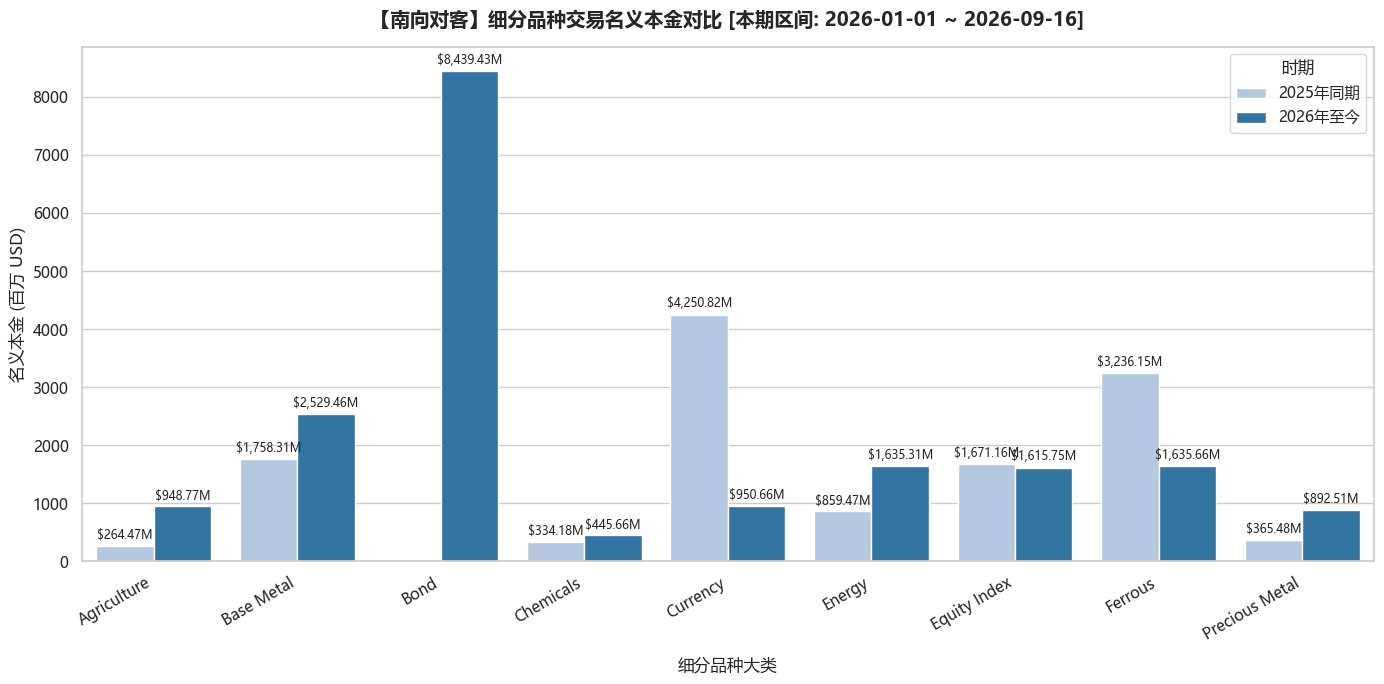

【统计一：全部 Category 加总数值与增长率】
• 2025年同期 Total Notional      : 12,740.04 MM
• 2026年至今 Total Notional    : 19,093.21 MM
• 绝对增减额                  : +6,353.16 MM
• 增长百分比 (%)               : +49.87%


In [13]:
# 2. 调用通用周期对比函数 (此处演示周同比 mode='YoY_Week')
#    你也可以更换 mode 参数：'YoY_Year' (年同比), 'BiWeekly' (双周环比)
df_two_weeks_all, period_info = analyze_period_comparison(df, mode='YoY_Year', date_col='交易日期')

# 3. 筛选并导出南向对客与对冲的两周明细
if not df_two_weeks_all.empty:
    df_filtered = df_two_weeks_all[
        df_two_weeks_all['簿记账户'].astype(str).str.contains('南向对客|南向对冲', na=False)
    ]
    df_filtered[existing_cols + ['Period']].to_excel("本周与上年同周交易明细_南向对客与对冲.xlsx", index=False)

    # 4. 独立调用绘图函数
    summary_df = plot_client_comparison(df_two_weeks_all, period_info)
    pivot_df = calculate_growth(summary_df, period_info)


In [14]:
# pivot_df.round(2)

# 2. Trading PnL


In [15]:
def calculate_weekly_trading_pnl(trades):
    """客户带方向名义本金 - 本方对冲带方向名义本金，排除 XUC。

    本周沿用周报口径：全量流水最近 5 个有交易记录的日期。
    未做逐笔配对、持仓市值重估或手续费扣减；未抵消数量单独展示。
    """
    required = [
        '交易日期', '簿记账户', 'bbg_ticker', '买卖方向',
        '价格', '手数', 'Contract_Size', 'FX_Rate_to_USD', 'Category',
    ]
    missing = [c for c in required if c not in trades.columns]
    if missing:
        raise ValueError(f"交易 PnL 缺少字段：{missing}")
    work = trades.copy()
    work['交易日期'] = pd.to_datetime(work['交易日期'], errors='coerce')
    if work['交易日期'].isna().any():
        raise ValueError("交易日期包含缺失或无效值，无法确定本周范围。")
    dates = sorted(work['交易日期'].dt.normalize().unique())[-5:]
    if not dates:
        raise ValueError("没有交易记录，无法计算本周 PnL。")
    week = work[work['交易日期'].dt.normalize().isin(dates)].copy()
    account = week['簿记账户'].astype('string').str.strip()
    # 与前面的周报一样按账户名称包含关系筛选。
    client = account.str.contains('南向对客', na=False)
    hedge = account.str.contains('南向对冲', na=False)
    if (client & hedge).any():
        raise ValueError("同一账户同时匹配南向对客和南向对冲，请检查账户名称。")
    week['交易侧'] = np.where(client, '南向对客', '南向对冲')
    week = week[client | hedge].copy()
    ticker = week['bbg_ticker'].astype('string').str.strip()
    if (ticker.isna() | ticker.eq('')).any():
        raise ValueError("本周对客/对冲记录缺少标的代码，无法过滤 XUC。")
    xuc = ticker.str.upper().str.startswith('XUC', na=False)
    excluded = week[xuc].copy()
    detail = week[~xuc].copy()

    direction = detail['买卖方向'].astype('string').str.strip().str.upper()
    signs = direction.map({'B': 1, 'S': -1, '买': 1, '卖': -1, '买入': 1, '卖出': -1})
    if signs.isna().any():
        raise ValueError(f"无法识别的买卖方向：{detail.loc[signs.isna(), '买卖方向'].tolist()}")
    numeric = ['价格', '手数', 'Contract_Size', 'FX_Rate_to_USD']
    for col in numeric:
        detail[col] = pd.to_numeric(detail[col], errors='coerce')
        if not np.isfinite(detail[col]).all():
            raise ValueError(f"{col} 包含缺失或无效值。")
    for col in ['Contract_Size', 'FX_Rate_to_USD']:
        if detail[col].le(0).any():
            raise ValueError(f"{col} 必须为正数。")

    detail['方向符号'] = signs.astype(float)
    # 方向只由买卖方向字段决定，避免手数自带负号时重复处理。
    # 保留价格本身的正负号，兼容负价格交易。
    detail['带方向手数'] = detail['手数'].abs() * detail['方向符号']
    detail['PnL口径名义本金_USD'] = (
        detail['价格'] * detail['手数'].abs()
        * detail['Contract_Size'] * detail['FX_Rate_to_USD']
    )
    # 对客为客户方向，对冲为本方方向：客户带方向金额减对冲带方向金额。
    detail['带方向名义本金_USD'] = detail['方向符号'] * detail['PnL口径名义本金_USD']
    side_factor = np.where(detail['交易侧'].eq('南向对客'), 1.0, -1.0)
    detail['交易现金流_USD'] = side_factor * detail['带方向名义本金_USD']
    detail['本方带方向手数'] = -side_factor * detail['带方向手数']
    if not np.isfinite(detail['交易现金流_USD']).all():
        raise ValueError("PnL 金额超出有效数值范围。")
    detail['Category'] = detail['Category'].fillna('Unclassified')

    def cash_summary(keys):
        result = detail.pivot_table(
            index=keys, columns='交易侧', values='交易现金流_USD',
            aggfunc='sum', fill_value=0,
        ).reindex(columns=['南向对客', '南向对冲'], fill_value=0)
        result.columns = ['对客现金流_USD', '对冲现金流_USD']
        result['交易PnL_USD'] = result.sum(axis=1)
        return result

    by_category = cash_summary(['Category'])
    by_contract = cash_summary(['bbg_ticker'])
    quantities = detail.groupby('bbg_ticker')['本方带方向手数'].sum()
    by_contract['本方净手数_买正卖负'] = quantities
    by_contract['数量已抵消'] = np.isclose(quantities, 0.0, rtol=0, atol=1e-8)
    # 现金流汇总是用户指定的价差口径；不把单边交易默认为已实现收益。
    unmatched = by_contract[~by_contract['数量已抵消']].copy()
    info = {
        '开始日期': pd.Timestamp(dates[0]).date(),
        '结束日期': pd.Timestamp(dates[-1]).date(),
        '有记录日期数': len(dates),
        '参与计算记录数': len(detail),
        '排除XUC记录数': len(excluded),
        '对客现金流_USD': detail.loc[detail['交易侧'].eq('南向对客'), '交易现金流_USD'].sum(),
        '对冲现金流_USD': detail.loc[detail['交易侧'].eq('南向对冲'), '交易现金流_USD'].sum(),
        '交易PnL_USD': detail['交易现金流_USD'].sum(),
    }
    return info, detail, by_category, by_contract, unmatched, excluded


# 本单元格使用前面已完成美元换算的 df，在线和离线模式共用。
from IPython.display import display

pnl_info, pnl_detail, pnl_by_category, pnl_by_contract, pnl_unmatched, pnl_excluded_xuc = (
    calculate_weekly_trading_pnl(df)
)
print(f"本周交易 PnL：{pnl_info['开始日期']} ~ {pnl_info['结束日期']}"
      f"（{pnl_info['有记录日期数']} 个有记录日期）")
print(f"参与计算 {pnl_info['参与计算记录数']} 条，排除 XUC {pnl_info['排除XUC记录数']} 条")
print(f"对客现金流：{pnl_info['对客现金流_USD']:,.2f} USD")
print(f"对冲现金流：{pnl_info['对冲现金流_USD']:,.2f} USD")
print(f"交易 PnL：{pnl_info['交易PnL_USD']:+,.2f} USD（正数盈利、负数亏损）")
# 分类按总 PnL 降序；类内标的按 PnL 降序，按美元分展示非零金额。
pnl_by_category = pnl_by_category.sort_values('交易PnL_USD', ascending=False)
pnl_category_tickers = (
    pnl_detail.groupby(['Category', 'bbg_ticker'], as_index=False)['交易现金流_USD']
    .sum().rename(columns={'bbg_ticker': '标的名称', '交易现金流_USD': '交易PnL_USD'})
)
# 用显示精度判断零，避免浮点误差或不足半美分的金额显示为 0.00。
pnl_category_tickers = pnl_category_tickers[
    pnl_category_tickers['交易PnL_USD'].round(2).ne(0)
].copy()
pnl_category_tickers['类别顺序'] = pnl_category_tickers['Category'].map(
    {category: rank for rank, category in enumerate(pnl_by_category.index)}
)
pnl_category_tickers = pnl_category_tickers.sort_values(
    ['类别顺序', '交易PnL_USD', '标的名称'], ascending=[True, False, True]
).drop(columns='类别顺序').reset_index(drop=True)

print("分类汇总（PnL 从大到小）：")
display(pnl_by_category.round(2))
print("各类别非零 PnL 标的（USD，按两位小数筛选；类内从大到小）：")
for category in pnl_by_category.index:
    category_tickers = pnl_category_tickers.loc[
        pnl_category_tickers['Category'].eq(category), ['标的名称', '交易PnL_USD']
    ]
    print(f"\n{category} | 类别 PnL：{pnl_by_category.loc[category, '交易PnL_USD']:+,.2f} USD")
    if category_tickers.empty:
        print("无非零 PnL 标的。")
    else:
        display(category_tickers.reset_index(drop=True).style.format({'交易PnL_USD': '{:,.2f}'}))
# print("合约明细：")
# display(pnl_by_contract.round(2))
if not pnl_unmatched.empty:
    print(f"注意：{len(pnl_unmatched)} 个合约本周数量未抵消，"
          "上述结果包含单边现金流，不能全部视为已配对交易利润；请核对跨周或未完成对冲。")
    display(pnl_unmatched.round(2))


本周交易 PnL：2026-09-10 ~ 2026-09-16（5 个有记录日期）
参与计算 404 条，排除 XUC 4 条
对客现金流：-87,913,007.67 USD
对冲现金流：87,915,092.38 USD
交易 PnL：+2,084.71 USD（正数盈利、负数亏损）
分类汇总（PnL 从大到小）：


,对客现金流_USD,对冲现金流_USD,交易PnL_USD
Category,,,
Base Metal,-13484193.15,13485472.90,1279.75
Agriculture,-884670.07,885298.90,628.83
Ferrous,8233392.47,-8233300.00,92.47
Bond,-54292663.44,54292715.09,51.65
Energy,-35076480.20,35076510.00,29.80
Currency,2005695.95,-2005693.75,2.20
Chemicals,5808000.00,-5808000.00,0.00
Equity Index,-5379.23,5379.23,0.00
Precious Metal,-216710.00,216710.00,0.00


各类别非零 PnL 标的（USD，按两位小数筛选；类内从大到小）：

Base Metal | 类别 PnL：+1,279.75 USD


,标的名称,交易PnL_USD
0,LMNIDP 20261215 Comdty,"230,580.00"
1,LMZSDP 20261118 Comdty,"4,575.00"
2,LMZSDP 20261216 Comdty,"2,087.55"
3,HGZ6 Comdty,237.50
4,LMZSDP 20261211 Comdty,"-6,587.50"
5,LMNIDP 20261118 Comdty,"-229,612.80"



Agriculture | 类别 PnL：+628.83 USD


...


Energy | 类别 PnL：+29.80 USD


,标的名称,交易PnL_USD
0,CLV6 Comdty,30.00
1,AZBV26 Comdty,-0.20



Currency | 类别 PnL：+2.20 USD


,标的名称,交易PnL_USD
0,CDZ6 Curncy,2.00
1,DXZ6 Curncy,0.20



Chemicals | 类别 PnL：+0.00 USD
无非零 PnL 标的。

Equity Index | 类别 PnL：+0.00 USD
无非零 PnL 标的。

Precious Metal | 类别 PnL：+0.00 USD
无非零 PnL 标的。


# 3. 本周前五客户及交易品种排名


In [16]:
def calculate_weekly_notional_rankings(trades, top_n=5):
    """本周南向对客排名；成交量用美元名义本金绝对值，买卖不抵消。"""
    required = ['交易日期', '簿记账户', '客户简称', 'bbg_ticker', 'Generic_Ticker', 'Notional']
    missing = [col for col in required if col not in trades.columns]
    if missing:
        raise ValueError(f"本周交易排名缺少字段：{missing}")
    work = trades.copy()
    work['交易日期'] = pd.to_datetime(work['交易日期'], errors='coerce')
    if work['交易日期'].isna().any():
        raise ValueError("存在无效交易日期，无法确定本周区间。")
    dates = sorted(work['交易日期'].dt.normalize().unique())[-5:]
    if not dates:
        raise ValueError("没有交易记录，无法生成排名。")
    account = work['簿记账户'].astype('string').str.strip()
    client_mask = account.str.contains('南向对客', na=False)
    hedge_mask = account.str.contains('南向对冲', na=False)
    if (client_mask & hedge_mask).any():
        raise ValueError("账户同时匹配对客与对冲，请核对账户名称。")
    detail = work[
        work['交易日期'].dt.normalize().isin(dates) & client_mask
    ].copy()
    detail['成交名义本金_USD'] = pd.to_numeric(detail['Notional'], errors='coerce').abs()
    if not np.isfinite(detail['成交名义本金_USD']).all():
        raise ValueError("Notional 包含缺失或无效数值。")
    for col in ['客户简称', 'bbg_ticker', 'Generic_Ticker']:
        detail[col] = detail[col].astype('string').str.strip()
        if (detail[col].isna() | detail[col].eq('')).any():
            raise ValueError(f"{col} 有空值，请补齐后生成排名，避免遗漏交易。")

    def rank_by(key):
        table = detail.groupby(key, as_index=False).agg(
            Notional_USD=('成交名义本金_USD', 'sum'),
            交易笔数=('成交名义本金_USD', 'size'),
        ).sort_values(['Notional_USD', key], ascending=[False, True]).head(top_n)
        table = table.reset_index(drop=True)
        table.insert(0, '排名', np.arange(1, len(table) + 1))
        table['Notional_百万USD'] = table['Notional_USD'] / 1e6
        return table

    top_clients = rank_by('客户简称')
    client_tickers = (
        detail[detail['客户简称'].isin(top_clients['客户简称'])]
        .groupby(['客户简称', 'bbg_ticker'], as_index=False)
        .agg(Notional_USD=('成交名义本金_USD', 'sum'),
             交易笔数=('成交名义本金_USD', 'size'))
    )
    client_order = dict(zip(top_clients['客户简称'], top_clients['排名']))
    client_tickers['客户排名'] = client_tickers['客户简称'].map(client_order)
    client_tickers = client_tickers.sort_values(
        ['客户排名', 'Notional_USD', 'bbg_ticker'], ascending=[True, False, True]
    ).reset_index(drop=True)
    client_tickers['Notional_百万USD'] = client_tickers['Notional_USD'] / 1e6
    names = client_tickers.groupby('客户简称')['bbg_ticker'].agg(lambda items: '、'.join(items))
    top_clients['交易标的'] = top_clients['客户简称'].map(names)
    top_tickers = rank_by('bbg_ticker')
    top_products = rank_by('Generic_Ticker')
    info = {
        '开始日期': pd.Timestamp(dates[0]).date(),
        '结束日期': pd.Timestamp(dates[-1]).date(),
        '有记录日期数': len(dates),
        '对客记录数': len(detail),
        '客户数': detail['客户简称'].nunique(),
        '总成交名义本金_USD': detail['成交名义本金_USD'].sum(),
    }
    return info, top_clients, client_tickers, top_tickers, top_products


from IPython.display import display

ranking_info, top5_clients, top5_client_tickers, top5_tickers, top5_products = (
    calculate_weekly_notional_rankings(df)
)
print(f"本周交易排名：{ranking_info['开始日期']} ~ {ranking_info['结束日期']}"
      f"（{ranking_info['有记录日期数']} 个有记录日期）")
print("统计南向对客；按美元名义本金绝对值加总，买卖不抵消，不计入南向对冲。")
print(f"客户数：{ranking_info['客户数']}；对客交易：{ranking_info['对客记录数']} 笔")
print(f"总成交名义本金：{ranking_info['总成交名义本金_USD']:,.2f} USD")
if top5_clients.empty:
    print("本周没有南向对客交易。")
else:
    print("一、成交名义本金前五客户：")
    # 仅在这个 block 块内临时解除限制
    with pd.option_context('display.max_rows', None, 
                        'display.max_columns', None, 
                        'display.max_colwidth', None):
        display(top5_clients)
    # print("各客户交易标的（按该客户在该标的上的名义本金降序）：")
    # for customer in top5_clients['客户简称']:
    #     print(f"客户：{customer}")
    #     display(top5_client_tickers.loc[
    #         top5_client_tickers['客户简称'].eq(customer),
    #         ['bbg_ticker', 'Notional_USD', 'Notional_百万USD', '交易笔数']
    #     ].reset_index(drop=True))
    # print("二、按具体标的汇总的前五名：")
    # display(top5_tickers)
    print("二、以名义本金衡量的交易量前五大品种：")
    display(top5_products)


本周交易排名：2026-09-10 ~ 2026-09-16（5 个有记录日期）
统计南向对客；按美元名义本金绝对值加总，买卖不抵消，不计入南向对冲。
客户数：68；对客交易：274 笔
总成交名义本金：325,057,283.51 USD
一、成交名义本金前五客户：


,排名,客户简称,Notional_USD,交易笔数,Notional_百万USD,交易标的
0,1,浙江永安资本管理有限公司,5.640369e+07,5,56.403689,TYZ6 Comdty、SCOU6 Comdty、SCOV6 Comdty
1,2,北京雪球厚雪宏观对冲私募证券投资基金FX,4.400237e+07,2,44.002374,USZ6 Comdty、CLV6 Comdty
2,3,埃珂森,4.319362e+07,6,43.193620,LMNIDP 20260916 Comdty、LMNIDP 20261216 Comdty、LMNIDP 20261021 Comdty、LMNIDP 20270421 Comdty
3,4,北京雪球厚雪宏观对冲2号私募证券投资基金FX,1.606875e+07,2,16.068752,USZ6 Comdty、CLV6 Comdty
4,5,浙江物产永利实业,1.259200e+07,11,12.592000,CJPV26 Comdty、CJPX26 Comdty、BBWF27 Comdty、BBWH27 Comdty


二、以名义本金衡量的交易量前五大品种：


,排名,Generic_Ticker,Notional_USD,交易笔数,Notional_百万USD
0,1,LMNIDY Comdty,5.870397e+07,14,58.703966
1,2,US1 Comdty,5.296675e+07,27,52.966749
2,3,SB1 Comdty,3.723905e+07,105,37.239052
3,4,TY1 Comdty,3.588703e+07,9,35.887031
4,5,SCO1 Comdty,3.133239e+07,5,31.332392


## 本周大额交易：开平仓、客户方向、手数与客户平仓盈亏
通过流水编号匹配，核对客户编号、标的、价格与手数。平仓记录拆分后先汇总；缺失或冲突明确标注。


In [17]:
# 将本周排名关联到开仓、平仓记录。保留逐笔明细，汇总不会重复计入 Notional。
from trade_lifecycle import read_position_file, classify_trades, summarize_position_activity

opening_records = read_position_file(OPEN_POSITION_FILE)
closing_records = read_position_file(CLOSE_POSITION_FILE)

trade_dates = pd.to_datetime(df['交易日期'], errors='raise').dt.normalize()
week_dates = sorted(trade_dates.unique())[-5:]
weekly_customer_trades = df[
    trade_dates.isin(week_dates) &
    df['簿记账户'].astype(str).str.strip().eq('南向对客')
].copy()

weekly_trade_lifecycle, lifecycle_match_summary = classify_trades(
    weekly_customer_trades, opening_records, closing_records
)
weekly_trade_lifecycle['Notional_USD'] = weekly_trade_lifecycle['Notional'].abs()
top5_individual_trades = weekly_trade_lifecycle.sort_values(
    ['Notional_USD', '流水编号'], ascending=[False, True]
).head(5).copy()
top5_clients_trade_details = weekly_trade_lifecycle[
    weekly_trade_lifecycle['客户简称'].isin(top5_clients['客户简称'])
].copy()
top5_products_trade_details = weekly_trade_lifecycle[
    weekly_trade_lifecycle['Generic_Ticker'].isin(top5_products['Generic_Ticker'])
].copy()
top5_clients_position_summary = summarize_position_activity(top5_clients_trade_details)
top5_products_position_summary = summarize_position_activity(top5_products_trade_details)

view_columns = [
    '交易日期', '客户简称', 'bbg_ticker', '客户交易方向', '交易手数',
    'Notional_USD', '开平仓', '已匹配开仓手数', '已匹配平仓手数',
    '待确认手数', '客户平仓盈亏_结算未扣费用', '盈亏结算币种', '盈亏覆盖范围',
    '流水编号',
]
print("四、本周大额交易的开平仓与客户平仓盈亏")
print(f"开仓来源：{OPEN_POSITION_FILE}")
print(f"平仓来源：{CLOSE_POSITION_FILE}")
print("方向取交易流水中的客户买卖方向；盈亏取平仓表“浮动收益（结算 未扣除费用）”。")
print("Notional 为 USD；客户平仓盈亏保留原结算币种，不是本方交易价差 PnL。")
print("部分匹配只展示已匹配平仓手数的盈亏；未匹配不能推断为开仓或平仓。")

# 客户较多时避免截断标的和匹配信息；金额保持数值类型，展示时加千分位。
with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                       'display.max_colwidth', None, 'display.float_format', '{:,.2f}'.format):
    print("匹配覆盖情况：")
    display(lifecycle_match_summary)
    print("按名义本金排名前五的单笔客户交易：")
    display(top5_individual_trades[view_columns].reset_index(drop=True))

    print("前五客户的标的、方向、手数和开平仓明细汇总：")
    for customer in top5_clients['客户简称']:
        print(f"客户：{customer}")
        display(top5_clients_position_summary[
            top5_clients_position_summary['客户简称'].eq(customer)
        ].reset_index(drop=True))

    print("前五品种的逐笔客户交易（同一品种内按名义本金降序）：")
    for product in top5_products['Generic_Ticker']:
        print(f"品种：{product}")
        product_detail = top5_products_trade_details[
            top5_products_trade_details['Generic_Ticker'].eq(product)
        ].sort_values(['Notional_USD', '流水编号'], ascending=[False, True])
        display(product_detail[view_columns].reset_index(drop=True))

    lifecycle_unresolved = weekly_trade_lifecycle[
        weekly_trade_lifecycle['开平仓'].isin(['未匹配', '待核对']) |
        weekly_trade_lifecycle['开平仓'].str.startswith('部分匹配', na=False)
    ]
    if not lifecycle_unresolved.empty:
        print(f"仍有 {len(lifecycle_unresolved)} 笔未完全核对；可查看 lifecycle_unresolved 补充源文件。")


e:\Users\hanqiuchen\AppData\Local\anaconda3\envs\py39\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


四、本周大额交易的开平仓与客户平仓盈亏
开仓来源：镒链系统20260916开仓导出.xlsb
平仓来源：平仓_20260916.xlsx
方向取交易流水中的客户买卖方向；盈亏取平仓表“浮动收益（结算 未扣除费用）”。
Notional 为 USD；客户平仓盈亏保留原结算币种，不是本方交易价差 PnL。
部分匹配只展示已匹配平仓手数的盈亏；未匹配不能推断为开仓或平仓。
匹配覆盖情况：


,开平仓,匹配状态,交易笔数
0,平仓,流水编号及字段、手数核对通过,135
1,开仓,流水编号及字段、手数核对通过,137
2,未匹配,开仓/平仓文件均未找到该流水编号,2


按名义本金排名前五的单笔客户交易：


,交易日期,客户简称,bbg_ticker,客户交易方向,交易手数,Notional_USD,开平仓,已匹配开仓手数,已匹配平仓手数,待确认手数,客户平仓盈亏_结算未扣费用,盈亏结算币种,盈亏覆盖范围,流水编号
0,2026-09-11,北京雪球厚雪宏观对冲私募证券投资基金FX,USZ6 Comdty,卖出,280.00,"30,249,654.40",开仓,280.00,0.00,0.00,NaN,,开仓不适用,20260911_100040904_USZ6 Comdty.CBOT_S_0
1,2026-09-16,浙江永安资本管理有限公司,SCOU6 Comdty,买入,"1,819.00","17,551,767.47",平仓,0.00,"1,819.00",0.00,"1,230,659.53",CNY,仅覆盖已匹配平仓 1819 手,20260916_100008005_SCOU6 Comdty.SGX_B_0
2,2026-09-16,浙江永安资本管理有限公司,TYZ6 Comdty,卖出,138.00,"14,612,906.25",平仓,0.00,138.00,0.00,"-426,642.71",CNY,仅覆盖已匹配平仓 138 手,20260916_100008005_TYZ6 Comdty.CBOT_S_0
3,2026-09-10,北京雪球厚雪宏观对冲私募证券投资基金FX,CLV6 Comdty,卖出,144.00,"13,752,720.00",平仓,0.00,144.00,0.00,"12,006,026.32",CNY,仅覆盖已匹配平仓 144 手,20260910_100040904_CLV6 Comdty.NYMEX_S_0
4,2026-09-11,北京雪球厚雪宏观对冲2号私募证券投资基金FX,USZ6 Comdty,卖出,101.00,"10,911,482.48",开仓,101.00,0.00,0.00,NaN,,开仓不适用,20260911_100049227_USZ6 Comdty.CBOT_S_0


...

品种：TY1 Comdty


,交易日期,客户简称,bbg_ticker,客户交易方向,交易手数,Notional_USD,开平仓,已匹配开仓手数,已匹配平仓手数,待确认手数,客户平仓盈亏_结算未扣费用,盈亏结算币种,盈亏覆盖范围,流水编号
0,2026-09-16,浙江永安资本管理有限公司,TYZ6 Comdty,卖出,138.00,"14,612,906.25",平仓,0.00,138.00,0.00,"-426,642.71",CNY,仅覆盖已匹配平仓 138 手,20260916_100008005_TYZ6 Comdty.CBOT_S_0
1,2026-09-11,浙江永安资本管理有限公司,TYZ6 Comdty,买入,69.00,"7,338,796.88",开仓,69.00,0.00,0.00,NaN,,开仓不适用,20260911_100008005_TYZ6 Comdty.CBOT_B_1
2,2026-09-11,浙江永安资本管理有限公司,TYZ6 Comdty,买入,69.00,"7,337,718.75",开仓,69.00,0.00,0.00,NaN,,开仓不适用,20260911_100008005_TYZ6 Comdty.CBOT_B_0
3,2026-09-14,恒德添益通盈1号私募证券投资基金,TYZ6 Comdty,买入,40.00,"4,254,140.63",开仓,40.00,0.00,0.00,NaN,,开仓不适用,20260914_100024843_TYZ6 Comdty.CBOT_B_0
4,2026-09-10,昊恩向日葵1号私募证券投资基金,TYZ6 Comdty,卖出,5.00,"535,234.38",开仓,5.00,0.00,0.00,NaN,,开仓不适用,20260910_100070156_TYZ6 Comdty.CBOT_S_0
5,2026-09-11,旌安正远私募证券投资基金,TYZ6 Comdty,卖出,5.00,"533,125.00",平仓,0.00,5.00,0.00,"-52,680.37",CNY,仅覆盖已匹配平仓 5 手,20260911_100019675_TYZ6 Comdty.CBOT_S_0
6,2026-09-14,昊恩向日葵1号私募证券投资基金,TYZ6 Comdty,卖出,5.00,"531,796.88",开仓,5.00,0.00,0.00,NaN,,开仓不适用,20260914_100070156_TYZ6 Comdty.CBOT_S_0
7,2026-09-16,昊恩向日葵1号私募证券投资基金,TYZ6 Comdty,买入,5.00,"530,312.50",平仓,0.00,5.00,0.00,"33,012.15",CNY,仅覆盖已匹配平仓 5 手,20260916_100070156_TYZ6 Comdty.CBOT_B_0
8,2026-09-14,君圭北斗1号私募证券投资基金,TYZ6 Comdty,卖出,2.00,"213,000.00",平仓,0.00,2.00,0.00,"-27,599.47",CNY,仅覆盖已匹配平仓 2 手,20260914_100051551_TYZ6 Comdty.CBOT_S_0


品种：SCO1 Comdty


,交易日期,客户简称,bbg_ticker,客户交易方向,交易手数,Notional_USD,开平仓,已匹配开仓手数,已匹配平仓手数,待确认手数,客户平仓盈亏_结算未扣费用,盈亏结算币种,盈亏覆盖范围,流水编号
0,2026-09-16,浙江永安资本管理有限公司,SCOU6 Comdty,买入,"1,819.00","17,551,767.47",平仓,0.00,"1,819.00",0.00,"1,230,659.53",CNY,仅覆盖已匹配平仓 1819 手,20260916_100008005_SCOU6 Comdty.SGX_B_0
1,2026-09-14,浙江永安资本管理有限公司,SCOV6 Comdty,卖出,"1,000.00","9,562,500.00",开仓,"1,000.00",0.00,0.00,NaN,,开仓不适用,20260914_100008005_SCOV6 Comdty.SGX_S_0
2,2026-09-10,宝钢资源控股（上海）有限公司,SCOV6 Comdty,卖出,200.00,"1,987,000.00",开仓,200.00,0.00,0.00,NaN,,开仓不适用,20260910_100033450_SCOV6 Comdty.SGX_S_0
3,2026-09-10,宝钢资源控股（上海）有限公司,SCOU6 Comdty,买入,200.00,"1,985,000.00",平仓,0.00,200.00,0.00,"46,934.16",CNY,仅覆盖已匹配平仓 200 手,20260910_100033450_SCOU6 Comdty.SGX_B_0
4,2026-09-10,点钢投资点睿5号私募证券投资基金,SCOV6 Comdty,买入,25.00,"246,125.00",开仓,25.00,0.00,0.00,NaN,,开仓不适用,20260910_100051935_SCOV6 Comdty.SGX_B_0


仍有 2 笔未完全核对；可查看 lifecycle_unresolved 补充源文件。


- 雪球卖出开仓美债，买入平仓WTI原油，获利1767万
- 埃珂森买入平仓伦镍，获利105万
- 永安资本卖出开仓铁矿
- 物产永利卖出平仓丙烷，获利989万；卖出平仓MOPJ，获利250万


1. 钱唐永利系列目前旗下共有13个户，只进行白糖交易，目前全部在盈利。他于8月中旬开始逐步建仓白糖多头，后于九月中旬移仓，平仓获利382万，目前持仓为1020手白糖多头。
2. 遂玖系列客户年初以来交易频繁，涉及品种较多，总体为盈利情况，YTD净获利1373万。主要盈利头寸为白糖多头、美棉多头、原油及柴油多头。目前持仓为926手美棉多头，283手白糖多头，220手咖啡多头，235手玉米多头。